<a href="https://colab.research.google.com/github/maverick8675309/srgan-binary-image-classification/blob/main/01_Binary_Classifier_A_Kelly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Artificial Intelligence and Deep Learning Midterm

## Binary Classifier A

This notebook builds the baseline transfer-learning model for a dogs-versus-cats binary classification problem.

The images are resized to 128 × 128, divided into a reproducible 70% training and 30% testing split, transformed, normalized, and used to train Model A.

Model A will later be compared with Model B, which will be trained using images generated by a Super-Resolution GAN.

# 1. Imports

In [1]:
import copy
import json
import os
import random
import time

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

print("Imports completed successfully.")

Imports completed successfully.


# 2. Connect Google Drive

In [16]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Project Paths and Directory Structure

In [3]:
PROJECT_ROOT = Path("/content/drive/MyDrive/AI_Midterm")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
MANIFEST_DIR = DATA_DIR / "manifests"
GENERATED_DATA_DIR = DATA_DIR / "generated"

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
CLASSIFIER_A_CHECKPOINT_DIR = CHECKPOINT_DIR / "classifier_A"
SRGAN_CHECKPOINT_DIR = CHECKPOINT_DIR / "srgan"
CLASSIFIER_B_CHECKPOINT_DIR = CHECKPOINT_DIR / "classifier_B"

FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
REPORT_DIR = PROJECT_ROOT / "report"

directories = [
    DATA_DIR,
    RAW_DATA_DIR,
    MANIFEST_DIR,
    GENERATED_DATA_DIR,
    CHECKPOINT_DIR,
    CLASSIFIER_A_CHECKPOINT_DIR,
    SRGAN_CHECKPOINT_DIR,
    CLASSIFIER_B_CHECKPOINT_DIR,
    FIGURES_DIR,
    RESULTS_DIR,
    NOTEBOOKS_DIR,
    REPORT_DIR,
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directories are ready.")
print("Project root:", PROJECT_ROOT)

Project directories are ready.
Project root: /content/drive/MyDrive/AI_Midterm


# 4. Reproducibility and Hardware Configuration

In [4]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Random seed:", SEED)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Random seed: 42
Device: cuda
GPU: NVIDIA A100-SXM4-80GB


# 5. Project Configuration

In [5]:
CONFIG = {
    "project_name": "SRGAN Binary Image Classification",
    "random_seed": SEED,
    "high_resolution_size": 128,
    "low_resolution_size": 32,
    "train_percentage": 0.70,
    "test_percentage": 0.30,
    "classifier_batch_size": 64,
    "classifier_learning_rate": 1e-4,
    "classifier_epochs": 10,
    "srgan_epochs": 150,
    "checkpoint_frequency": 5,
    "class_mapping": {
        "cats": 0,
        "dogs": 1,
    },
}

CONFIG_PATH = RESULTS_DIR / "project_config.json"

with open(CONFIG_PATH, "w") as file:
    json.dump(CONFIG, file, indent=4)

print(json.dumps(CONFIG, indent=4))
print("\nConfiguration saved to:")
print(CONFIG_PATH)

{
    "project_name": "SRGAN Binary Image Classification",
    "random_seed": 42,
    "high_resolution_size": 128,
    "low_resolution_size": 32,
    "train_percentage": 0.7,
    "test_percentage": 0.3,
    "classifier_batch_size": 64,
    "classifier_learning_rate": 0.0001,
    "classifier_epochs": 10,
    "srgan_epochs": 150,
    "checkpoint_frequency": 5,
    "class_mapping": {
        "cats": 0,
        "dogs": 1
    }
}

Configuration saved to:
/content/drive/MyDrive/AI_Midterm/results/project_config.json


# One-Time Dataset Setup

The following cells document the original ZIP upload, extraction, and manifest creation process. They do not need to be rerun after the dataset and manifests have been saved to Google Drive.

# ONE-TIME SETUP ONLY
# Do not rerun this cell unless the saved dataset is missing from Google Drive.

In [9]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [10]:
import zipfile
from pathlib import Path

# Name of uploaded file
uploaded_filename = next(iter(uploaded))

# Temporary ZIP in Colab
local_zip = Path("/content") / uploaded_filename

# Extract directly into Google Drive
EXTRACT_DIR = RAW_DATA_DIR / "extracted"
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(local_zip, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

DATASET_ROOT = EXTRACT_DIR / "dogs-vs-cats-classification"

print("Extraction complete.")
print(DATASET_ROOT)
print("Dataset exists:", DATASET_ROOT.exists())

Extraction complete.
/content/drive/MyDrive/AI_Midterm/data/raw/extracted/dogs-vs-cats-classification
Dataset exists: True


In [11]:
for split_name in ["train", "test"]:
    for class_name in ["cats", "dogs"]:
        folder = DATASET_ROOT / split_name / class_name

        image_count = len(
            list(folder.glob("*.jpg"))
        )

        print(
            f"{split_name:6} | "
            f"{class_name:5} | "
            f"{image_count:,} images"
        )

train  | cats  | 9,977 images
train  | dogs  | 9,966 images
test   | cats  | 1,248 images
test   | dogs  | 1,247 images


In [12]:
records = []

for original_split in ["train", "test"]:
    for class_name in ["cats", "dogs"]:

        folder = DATASET_ROOT / original_split / class_name

        label = 0 if class_name == "cats" else 1

        for image_path in sorted(folder.glob("*.jpg")):

            records.append({
                "image_path": str(image_path),
                "class_name": class_name,
                "label": label
            })

full_manifest = pd.DataFrame(records)

print("Total Images:", len(full_manifest))

Total Images: 22438


In [13]:
from sklearn.model_selection import train_test_split

train_manifest, test_manifest = train_test_split(
    full_manifest,
    test_size=0.30,
    random_state=42,
    stratify=full_manifest["label"]
)

train_manifest = train_manifest.reset_index(drop=True)
test_manifest = test_manifest.reset_index(drop=True)

print("Training:", len(train_manifest))
print("Testing :", len(test_manifest))

Training: 15706
Testing : 6732


In [14]:
MANIFEST_DIR.mkdir(
    parents=True,
    exist_ok=True
)

train_manifest.to_csv(
    MANIFEST_DIR / "train_70_percent.csv",
    index=False
)

test_manifest.to_csv(
    MANIFEST_DIR / "test_30_percent.csv",
    index=False
)

print("Training manifest saved.")
print("Testing manifest saved.")

Training manifest saved.
Testing manifest saved.


In [15]:
print(
    (MANIFEST_DIR / "train_70_percent.csv").exists()
)

print(
    (MANIFEST_DIR / "test_30_percent.csv").exists()
)

print(DATASET_ROOT.exists())

True
True
True


# Reusable Dataset Loading

The cells below are used in future sessions. They load the already extracted dataset and saved 70/30 manifests directly from Google Drive.

In [26]:
from pathlib import Path

DATASET_ROOT = Path(
    "/content/drive/MyDrive/AI_Midterm/data/raw/extracted/"
    "dogs-vs-cats-classification"
)

print("Dataset exists:", DATASET_ROOT.exists())
print("Dataset path:", DATASET_ROOT)

Dataset exists: True
Dataset path: /content/drive/MyDrive/AI_Midterm/data/raw/extracted/dogs-vs-cats-classification


In [18]:
for split_name in ["train", "test"]:
    for class_name in ["cats", "dogs"]:
        folder = DATASET_ROOT / split_name / class_name
        print(folder, "->", folder.exists())

/content/drive/MyDrive/AI_Midterm/data/raw/extracted/dogs-vs-cats-classification/train/cats -> True
/content/drive/MyDrive/AI_Midterm/data/raw/extracted/dogs-vs-cats-classification/train/dogs -> True
/content/drive/MyDrive/AI_Midterm/data/raw/extracted/dogs-vs-cats-classification/test/cats -> True
/content/drive/MyDrive/AI_Midterm/data/raw/extracted/dogs-vs-cats-classification/test/dogs -> True


In [19]:
if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        "The extracted dataset is missing from Google Drive. "
        "Do not continue until the saved Drive folder is located."
    )

print("Saved dataset found in Google Drive.")
print("No ZIP upload is required.")

Saved dataset found in Google Drive.
No ZIP upload is required.


In [22]:
DATASET_ROOT = Path(
    "/content/drive/MyDrive/AI_Midterm/data/raw/extracted/"
    "dogs-vs-cats-classification"
)

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_ROOT}"
    )

print("Saved dataset found in Google Drive.")
print("No ZIP upload is required.")

Saved dataset found in Google Drive.
No ZIP upload is required.


In [23]:
TRAIN_MANIFEST_PATH = (
    MANIFEST_DIR /
    "train_70_percent.csv"
)

TEST_MANIFEST_PATH = (
    MANIFEST_DIR /
    "test_30_percent.csv"
)

print("Training manifest:", TRAIN_MANIFEST_PATH.exists())
print("Testing manifest:", TEST_MANIFEST_PATH.exists())

Training manifest: True
Testing manifest: True


In [24]:
train_manifest = pd.read_csv(TRAIN_MANIFEST_PATH)
test_manifest = pd.read_csv(TEST_MANIFEST_PATH)

print(f"Training images: {len(train_manifest):,}")
print(f"Testing images:  {len(test_manifest):,}")

Training images: 15,706
Testing images:  6,732


# 6. Load the Saved 70/30 Dataset Split

## Reusable Project Setup

The dataset has already been extracted and stored in Google Drive, and the reproducible 70% training and 30% testing manifests have already been created.

These cells are used at the beginning of every future Colab session to reload the dataset and manifests without requiring the ZIP file to be uploaded or extracted again.

In [28]:
DATASET_ROOT = (
    RAW_DATA_DIR /
    "extracted" /
    "dogs-vs-cats-classification"
)

print("Dataset exists:", DATASET_ROOT.exists())
print(DATASET_ROOT)

Dataset exists: True
/content/drive/MyDrive/AI_Midterm/data/raw/extracted/dogs-vs-cats-classification


In [29]:
zip_candidates = list(RAW_DATA_DIR.glob("*.zip"))

print("ZIP files found:", len(zip_candidates))

for zip_path in zip_candidates:
    print(zip_path)

ZIP files found: 0


In [30]:
TRAIN_MANIFEST_PATH = MANIFEST_DIR / "train_70_percent.csv"
TEST_MANIFEST_PATH = MANIFEST_DIR / "test_30_percent.csv"

if not TRAIN_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Training manifest not found: {TRAIN_MANIFEST_PATH}"
    )

if not TEST_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Testing manifest not found: {TEST_MANIFEST_PATH}"
    )

train_manifest = pd.read_csv(TRAIN_MANIFEST_PATH)
test_manifest = pd.read_csv(TEST_MANIFEST_PATH)

print(f"Training images: {len(train_manifest):,}")
print(f"Testing images:  {len(test_manifest):,}")
print(f"Total images:    {len(train_manifest) + len(test_manifest):,}")

print("\nTraining class counts:")
print(train_manifest["class_name"].value_counts())

print("\nTesting class counts:")
print(test_manifest["class_name"].value_counts())

Training images: 15,706
Testing images:  6,732
Total images:    22,438

Training class counts:
class_name
cats    7857
dogs    7849
Name: count, dtype: int64

Testing class counts:
class_name
cats    3368
dogs    3364
Name: count, dtype: int64


# 7. Image Transformations and Normalization

The training images are resized to 128 × 128 and augmented to improve model generalization. Random horizontal flipping, slight rotation, and mild color adjustments introduce realistic variation without changing the image class.

The testing images are resized and normalized without random augmentation so that model evaluation remains consistent and reproducible.

ImageNet normalization is used because Model A will use a transfer-learning network pretrained on ImageNet.

In [31]:
IMAGE_SIZE = CONFIG["high_resolution_size"]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Training transformation:")
print(train_transform)

print("\nTesting transformation:")
print(test_transform)

Training transformation:
Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.9, 1.1), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Testing transformation:
Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 7.1 Transformation Summary

The training pipeline applies the following steps:

1. Resize each image to 128 × 128 pixels.
2. Randomly flip images horizontally.
3. Apply a small random rotation of up to 10 degrees.
4. Apply mild brightness, contrast, and saturation variation.
5. Convert each image to a PyTorch tensor.
6. Normalize the tensor using ImageNet statistics.

The testing pipeline only resizes, converts, and normalizes images.

In [32]:
display_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor()
])

print("Display transformation created.")

Display transformation created.


# 8. Custom PyTorch Dataset

A custom dataset class loads image paths and labels directly from the saved CSV manifests. The class applies the appropriate transformations when each image is retrieved.

In [33]:
class ManifestImageDataset(Dataset):
    def __init__(
        self,
        manifest,
        transform=None
    ):
        self.manifest = (
            manifest
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, index):
        row = self.manifest.iloc[index]

        image_path = Path(
            row["image_path"]
        )

        label = int(
            row["label"]
        )

        try:
            image = (
                Image
                .open(image_path)
                .convert("RGB")
            )

        except Exception as exc:
            raise RuntimeError(
                f"Unable to load image: {image_path}"
            ) from exc

        if self.transform is not None:
            image = self.transform(image)

        return image, label

# 9. Create Training and Testing Datasets

The saved manifests and transformation pipelines are used to create the PyTorch training and testing datasets.

In [34]:
train_dataset = ManifestImageDataset(
    manifest=train_manifest,
    transform=train_transform
)

test_dataset = ManifestImageDataset(
    manifest=test_manifest,
    transform=test_transform
)

print(
    f"Training dataset size: "
    f"{len(train_dataset):,}"
)

print(
    f"Testing dataset size:  "
    f"{len(test_dataset):,}"
)

Training dataset size: 15,706
Testing dataset size:  6,732


## 9.1 Verify a Transformed Image

A sample training image is inspected to confirm that it has three RGB channels and the required 128 × 128 dimensions.

In [35]:
sample_image, sample_label = (
    train_dataset[0]
)

class_names = {
    0: "Cat",
    1: "Dog"
}

print(
    "Image tensor shape:",
    sample_image.shape
)

print(
    "Label:",
    sample_label
)

print(
    "Class:",
    class_names[sample_label]
)

print(
    "Minimum tensor value:",
    sample_image.min().item()
)

print(
    "Maximum tensor value:",
    sample_image.max().item()
)

Image tensor shape: torch.Size([3, 128, 128])
Label: 1
Class: Dog
Minimum tensor value: -2.015155553817749
Maximum tensor value: 2.0648367404937744


# 10. Visualize Original and Transformed Images

The following figure compares resized original images with randomly transformed training images. This demonstrates the augmentation applied before Model A training.

In [36]:
IMAGENET_MEAN_ARRAY = np.array(
    IMAGENET_MEAN
)

IMAGENET_STD_ARRAY = np.array(
    IMAGENET_STD
)


def denormalize_image(image_tensor):
    image = (
        image_tensor
        .detach()
        .cpu()
        .numpy()
    )

    image = np.transpose(
        image,
        (1, 2, 0)
    )

    image = (
        image
        * IMAGENET_STD_ARRAY
        + IMAGENET_MEAN_ARRAY
    )

    return np.clip(
        image,
        0,
        1
    )

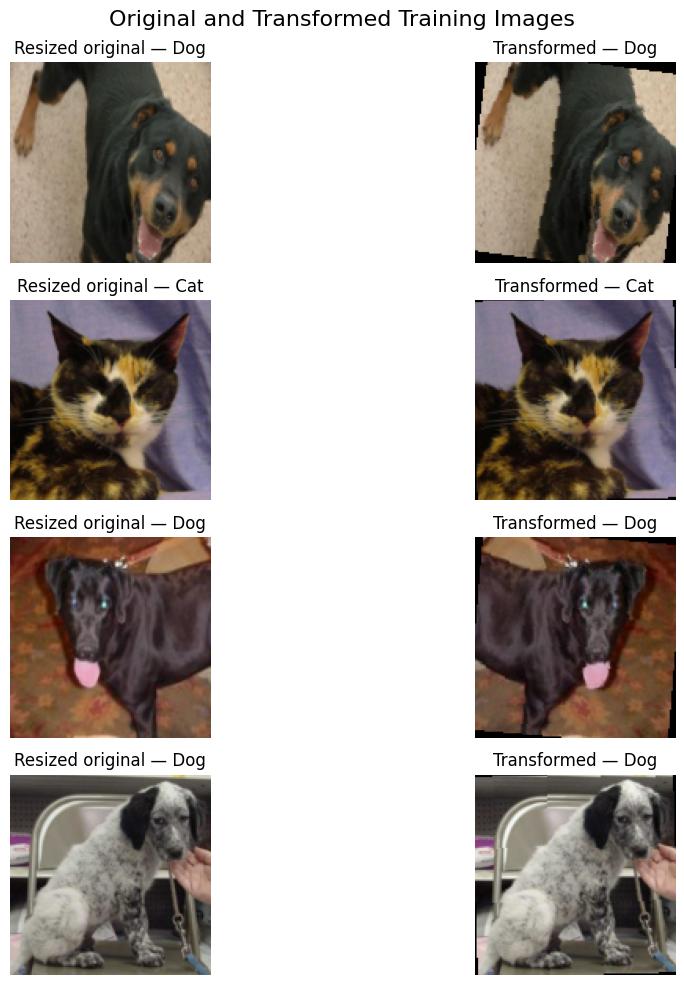

Figure saved to:
/content/drive/MyDrive/AI_Midterm/figures/original_vs_transformed_samples.png


In [37]:
sample_rows = (
    train_manifest
    .sample(
        n=4,
        random_state=SEED
    )
    .reset_index(drop=True)
)

plt.figure(
    figsize=(12, 10)
)

for index, row in sample_rows.iterrows():
    image_path = Path(
        row["image_path"]
    )

    label = int(
        row["label"]
    )

    original_image = (
        Image
        .open(image_path)
        .convert("RGB")
    )

    resized_image = (
        display_transform(
            original_image
        )
    )

    transformed_image = (
        train_transform(
            original_image
        )
    )

    plt.subplot(
        4,
        2,
        index * 2 + 1
    )

    plt.imshow(
        np.transpose(
            resized_image.numpy(),
            (1, 2, 0)
        )
    )

    plt.title(
        f"Resized original — "
        f"{class_names[label]}"
    )

    plt.axis("off")

    plt.subplot(
        4,
        2,
        index * 2 + 2
    )

    plt.imshow(
        denormalize_image(
            transformed_image
        )
    )

    plt.title(
        f"Transformed — "
        f"{class_names[label]}"
    )

    plt.axis("off")

plt.suptitle(
    "Original and Transformed "
    "Training Images",
    fontsize=16
)

plt.tight_layout()

comparison_path = (
    FIGURES_DIR
    / "original_vs_transformed_samples.png"
)

plt.savefig(
    comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved to:"
)

print(
    comparison_path
)

# 11. Create PyTorch DataLoaders

The DataLoaders divide the training and testing datasets into batches for efficient GPU processing. Training data are shuffled each epoch, while testing data remain in a fixed order.

In [38]:
BATCH_SIZE = CONFIG["classifier_batch_size"]
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 246
Testing batches: 106


## 11.1 Verify a Training Batch

A sample batch is inspected to confirm the expected batch size, image dimensions, and class-label distribution.

In [39]:
batch_images, batch_labels = next(iter(train_loader))

print("Batch image shape:", batch_images.shape)
print("Batch label shape:", batch_labels.shape)

unique_labels, label_counts = torch.unique(
    batch_labels,
    return_counts=True
)

print("\nClass counts in sample batch:")

for label, count in zip(unique_labels, label_counts):
    print(
        f"{class_names[label.item()]}: "
        f"{count.item()}"
    )

Batch image shape: torch.Size([64, 3, 128, 128])
Batch label shape: torch.Size([64])

Class counts in sample batch:
Cat: 28
Dog: 36


# 12. Build Transfer-Learning Classifier A

Classifier A uses a MobileNetV2 convolutional backbone pretrained on ImageNet. The pretrained feature extractor is initially frozen, and the final classification layer is replaced with a two-class output layer for cats and dogs.

In [40]:
from torchvision.models import (
    MobileNet_V2_Weights
)

weights = MobileNet_V2_Weights.DEFAULT

model_a = models.mobilenet_v2(
    weights=weights
)

for parameter in model_a.features.parameters():
    parameter.requires_grad = False

number_of_features = (
    model_a.classifier[1].in_features
)

model_a.classifier[1] = nn.Linear(
    number_of_features,
    2
)

model_a = model_a.to(device)

print(model_a.classifier)
print("\nModel device:", next(model_a.parameters()).device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 232MB/s]

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)

Model device: cuda:0


## 12.1 Confirm Trainable Parameters

Only the newly added classification layer is trainable during the initial transfer-learning stage.

In [41]:
trainable_parameters = sum(
    parameter.numel()
    for parameter in model_a.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in model_a.parameters()
)

print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters:     {total_parameters:,}")

print(
    f"Trainable percentage: "
    f"{trainable_parameters / total_parameters:.2%}"
)

Trainable parameters: 2,562
Total parameters:     2,226,434
Trainable percentage: 0.12%


# 13. Loss Function and Optimizer

Cross-entropy loss is used for binary classification with two output logits. Adam optimizes only the trainable classification-layer parameters.

In [42]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(
        lambda parameter: parameter.requires_grad,
        model_a.parameters()
    ),
    lr=CONFIG["classifier_learning_rate"]
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss function: CrossEntropyLoss()
Optimizer: Adam


## 13.1 Verify a GPU Forward Pass

A single training batch is transferred to the configured device and passed through the model to confirm that the transfer-learning pipeline is functioning correctly.

In [43]:
model_a.eval()

batch_images = batch_images.to(
    device,
    non_blocking=True
)

batch_labels = batch_labels.to(
    device,
    non_blocking=True
)

with torch.no_grad():
    batch_outputs = model_a(
        batch_images
    )

print("Input batch device:", batch_images.device)
print("Output shape:", batch_outputs.shape)
print("Output device:", batch_outputs.device)

Input batch device: cuda:0
Output shape: torch.Size([64, 2])
Output device: cuda:0


# 14. Train Classifier A

Classifier A is trained using the frozen MobileNetV2 feature extractor and the new two-class classification layer.

The best model is selected using testing loss and saved to Google Drive after each improvement.

In [44]:
NUM_EPOCHS = CONFIG["classifier_epochs"]

BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "classifier_A_best.pth"
)

FINAL_MODEL_PATH = (
    CHECKPOINT_DIR /
    "classifier_A_final.pth"
)

history_a = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": [],
}

best_test_loss = float("inf")
best_model_state = None

for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training phase
    # -------------------------
    model_a.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model_a(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_train_loss += (
            loss.item()
            * labels.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

    train_loss = (
        running_train_loss
        / train_total
    )

    train_accuracy = (
        train_correct
        / train_total
    )

    # -------------------------
    # Testing phase
    # -------------------------
    model_a.eval()

    running_test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model_a(images)

            loss = criterion(
                outputs,
                labels
            )

            running_test_loss += (
                loss.item()
                * labels.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            test_correct += (
                predictions == labels
            ).sum().item()

            test_total += labels.size(0)

    test_loss = (
        running_test_loss
        / test_total
    )

    test_accuracy = (
        test_correct
        / test_total
    )

    history_a["train_loss"].append(
        train_loss
    )

    history_a["train_accuracy"].append(
        train_accuracy
    )

    history_a["test_loss"].append(
        test_loss
    )

    history_a["test_accuracy"].append(
        test_accuracy
    )

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_accuracy:.4f}"
    )

    if test_loss < best_test_loss:
        best_test_loss = test_loss

        best_model_state = copy.deepcopy(
            model_a.state_dict()
        )

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": best_model_state,
                "optimizer_state_dict": optimizer.state_dict(),
                "test_loss": best_test_loss,
                "config": CONFIG,
            },
            BEST_MODEL_PATH
        )

        print(
            "Best model updated and saved."
        )

Epoch 01/10 | Train Loss: 0.4967 | Train Acc: 0.7900 | Test Loss: 0.3694 | Test Acc: 0.8694
Best model updated and saved.
Epoch 02/10 | Train Loss: 0.3369 | Train Acc: 0.8770 | Test Loss: 0.2991 | Test Acc: 0.8907
Best model updated and saved.
Epoch 03/10 | Train Loss: 0.2882 | Train Acc: 0.8906 | Test Loss: 0.2628 | Test Acc: 0.9037
Best model updated and saved.
Epoch 04/10 | Train Loss: 0.2642 | Train Acc: 0.8972 | Test Loss: 0.2498 | Test Acc: 0.9024
Best model updated and saved.
Epoch 05/10 | Train Loss: 0.2535 | Train Acc: 0.8991 | Test Loss: 0.2337 | Test Acc: 0.9086
Best model updated and saved.
Epoch 06/10 | Train Loss: 0.2422 | Train Acc: 0.9015 | Test Loss: 0.2217 | Test Acc: 0.9131
Best model updated and saved.
Epoch 07/10 | Train Loss: 0.2321 | Train Acc: 0.9062 | Test Loss: 0.2218 | Test Acc: 0.9116
Epoch 08/10 | Train Loss: 0.2206 | Train Acc: 0.9104 | Test Loss: 0.2120 | Test Acc: 0.9161
Best model updated and saved.
Epoch 09/10 | Train Loss: 0.2190 | Train Acc: 0.9104 |

## 14.1 Save Final Model and Training History

In [45]:
torch.save(
    {
        "epoch": NUM_EPOCHS,
        "model_state_dict": model_a.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history_a,
        "config": CONFIG,
    },
    FINAL_MODEL_PATH
)

history_path = (
    RESULTS_DIR /
    "classifier_A_history.json"
)

with open(history_path, "w") as file:
    json.dump(
        history_a,
        file,
        indent=4
    )

print("Final model saved to:")
print(FINAL_MODEL_PATH)

print("\nBest model saved to:")
print(BEST_MODEL_PATH)

print("\nTraining history saved to:")
print(history_path)

Final model saved to:
/content/drive/MyDrive/AI_Midterm/checkpoints/classifier_A_final.pth

Best model saved to:
/content/drive/MyDrive/AI_Midterm/checkpoints/classifier_A_best.pth

Training history saved to:
/content/drive/MyDrive/AI_Midterm/results/classifier_A_history.json


# 15. Load the Best Classifier A Checkpoint

The best-performing checkpoint is reloaded before final evaluation so the reported metrics reflect the strongest version of Model A.

In [46]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

model_a.load_state_dict(
    checkpoint["model_state_dict"]
)

model_a = model_a.to(device)
model_a.eval()

print(
    "Loaded best checkpoint from epoch:",
    checkpoint["epoch"]
)

print(
    "Best evaluation loss:",
    checkpoint["test_loss"]
)

Loaded best checkpoint from epoch: 10
Best evaluation loss: 0.2005791923056666


# 16. Generate Predictions for the Evaluation Set

The model generates predicted classes and dog-class probabilities for every image in the 30% evaluation set.

In [47]:
all_labels = []
all_predictions = []
all_probabilities = []

model_a.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model_a(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = outputs.argmax(
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities[:, 1]
            .cpu()
            .numpy()
        )

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

print(
    "Predictions generated:",
    len(all_predictions)
)

Predictions generated: 6732


# 17. Evaluate Classifier A

Classifier A is evaluated using accuracy, precision, recall, F1 score, and ROC-AUC.

In [48]:
accuracy_a = accuracy_score(
    all_labels,
    all_predictions
)

precision_a = precision_score(
    all_labels,
    all_predictions
)

recall_a = recall_score(
    all_labels,
    all_predictions
)

f1_a = f1_score(
    all_labels,
    all_predictions
)

roc_auc_a = roc_auc_score(
    all_labels,
    all_probabilities
)

metrics_a = {
    "model": "Classifier A",
    "accuracy": float(accuracy_a),
    "precision": float(precision_a),
    "recall": float(recall_a),
    "f1_score": float(f1_a),
    "roc_auc": float(roc_auc_a)
}

print("Classifier A Metrics\n")

for metric_name, metric_value in metrics_a.items():
    if metric_name != "model":
        print(
            f"{metric_name}: "
            f"{metric_value:.4f}"
        )

Classifier A Metrics

accuracy: 0.9190
precision: 0.9293
recall: 0.9070
f1_score: 0.9180
roc_auc: 0.9783


## 17.1 Classification Report

In [49]:
report_a = classification_report(
    all_labels,
    all_predictions,
    target_names=[
        "Cat",
        "Dog"
    ],
    digits=4
)

print(report_a)

              precision    recall  f1-score   support

         Cat     0.9092    0.9311    0.9201      3368
         Dog     0.9293    0.9070    0.9180      3364

    accuracy                         0.9190      6732
   macro avg     0.9193    0.9190    0.9190      6732
weighted avg     0.9193    0.9190    0.9190      6732



# 18. Confusion Matrix

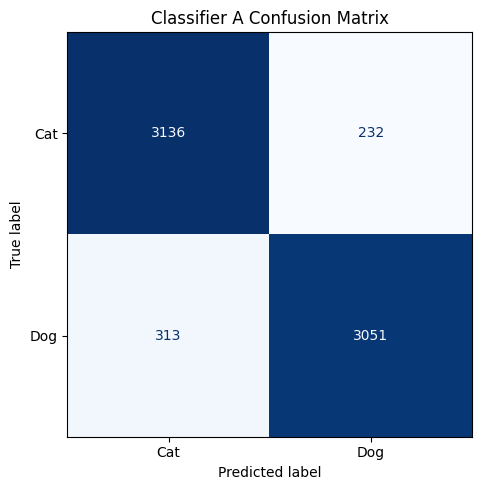

Confusion matrix saved to:
/content/drive/MyDrive/AI_Midterm/figures/classifier_A_confusion_matrix.png


In [50]:
confusion_a = confusion_matrix(
    all_labels,
    all_predictions
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

confusion_display = (
    __import__(
        "sklearn.metrics",
        fromlist=["ConfusionMatrixDisplay"]
    )
    .ConfusionMatrixDisplay(
        confusion_matrix=confusion_a,
        display_labels=[
            "Cat",
            "Dog"
        ]
    )
)

confusion_display.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Classifier A Confusion Matrix"
)

plt.tight_layout()

confusion_path = (
    FIGURES_DIR
    / "classifier_A_confusion_matrix.png"
)

plt.savefig(
    confusion_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Confusion matrix saved to:"
)

print(
    confusion_path
)

# 19. ROC Curve

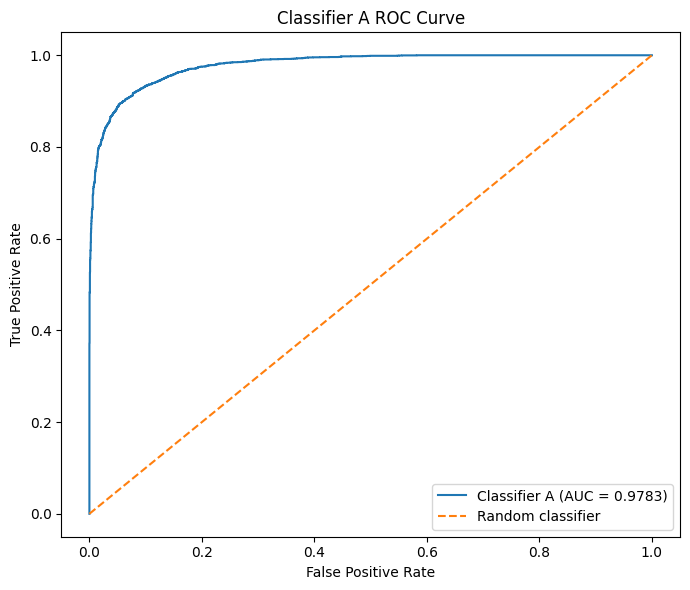

ROC curve saved to:
/content/drive/MyDrive/AI_Midterm/figures/classifier_A_roc_curve.png


In [51]:
false_positive_rate_a, true_positive_rate_a, _ = roc_curve(
    all_labels,
    all_probabilities
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    false_positive_rate_a,
    true_positive_rate_a,
    label=(
        f"Classifier A "
        f"(AUC = {roc_auc_a:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Classifier A ROC Curve"
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

roc_path = (
    FIGURES_DIR
    / "classifier_A_roc_curve.png"
)

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "ROC curve saved to:"
)

print(
    roc_path
)

# 20. Training History

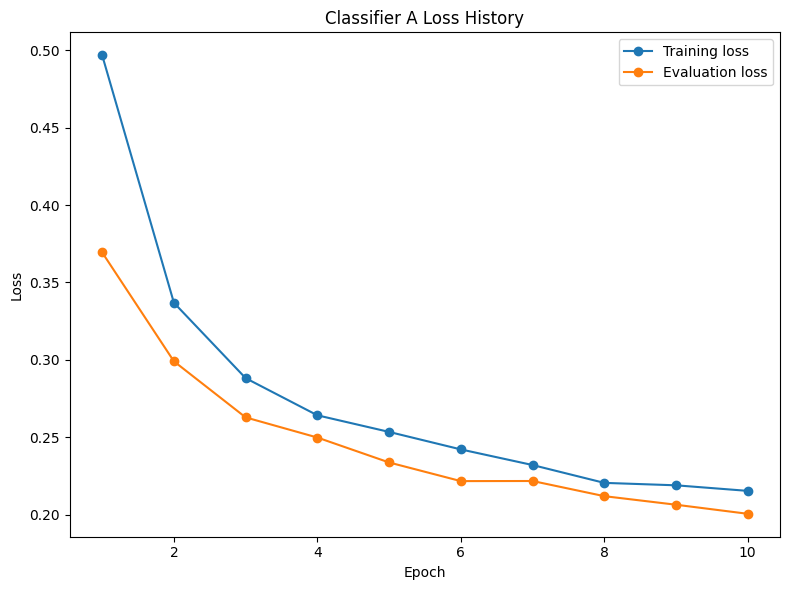

In [52]:
epochs = range(
    1,
    len(history_a["train_loss"]) + 1
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    epochs,
    history_a["train_loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    epochs,
    history_a["test_loss"],
    marker="o",
    label="Evaluation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classifier A Loss History")
plt.legend()
plt.tight_layout()

loss_history_path = (
    FIGURES_DIR
    / "classifier_A_loss_history.png"
)

plt.savefig(
    loss_history_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

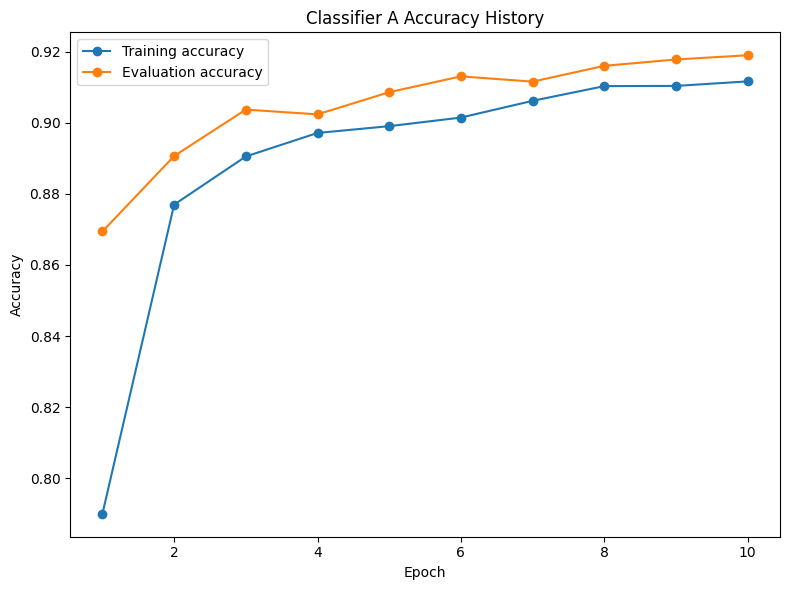

In [53]:
plt.figure(
    figsize=(8, 6)
)

plt.plot(
    epochs,
    history_a["train_accuracy"],
    marker="o",
    label="Training accuracy"
)

plt.plot(
    epochs,
    history_a["test_accuracy"],
    marker="o",
    label="Evaluation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Classifier A Accuracy History")
plt.legend()
plt.tight_layout()

accuracy_history_path = (
    FIGURES_DIR
    / "classifier_A_accuracy_history.png"
)

plt.savefig(
    accuracy_history_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 21. Save Classifier A Results

In [54]:
metrics_path = (
    RESULTS_DIR
    / "classifier_A_metrics.json"
)

with open(
    metrics_path,
    "w"
) as file:
    json.dump(
        metrics_a,
        file,
        indent=4
    )

predictions_path = (
    RESULTS_DIR
    / "classifier_A_predictions.csv"
)

predictions_dataframe = pd.DataFrame({
    "true_label": all_labels,
    "predicted_label": all_predictions,
    "dog_probability": all_probabilities
})

predictions_dataframe.to_csv(
    predictions_path,
    index=False
)

print(
    "Metrics saved to:"
)

print(
    metrics_path
)

print(
    "\nPredictions saved to:"
)

print(
    predictions_path
)

Metrics saved to:
/content/drive/MyDrive/AI_Midterm/results/classifier_A_metrics.json

Predictions saved to:
/content/drive/MyDrive/AI_Midterm/results/classifier_A_predictions.csv


In [55]:
files_to_verify = {
    "Best Classifier A checkpoint": BEST_MODEL_PATH,
    "Final Classifier A checkpoint": FINAL_MODEL_PATH,
    "Training history": RESULTS_DIR / "classifier_A_history.json",
    "Classifier A metrics": RESULTS_DIR / "classifier_A_metrics.json",
    "Classifier A predictions": RESULTS_DIR / "classifier_A_predictions.csv",
    "Confusion matrix": FIGURES_DIR / "classifier_A_confusion_matrix.png",
    "ROC curve": FIGURES_DIR / "classifier_A_roc_curve.png",
    "Loss history": FIGURES_DIR / "classifier_A_loss_history.png",
    "Accuracy history": FIGURES_DIR / "classifier_A_accuracy_history.png",
    "Training manifest": TRAIN_MANIFEST_PATH,
    "Testing manifest": TEST_MANIFEST_PATH,
}

all_files_found = True

for name, path in files_to_verify.items():
    exists = Path(path).exists()

    print(
        f"{name}: "
        f"{'FOUND' if exists else 'MISSING'}"
    )

    if not exists:
        all_files_found = False

print()

if all_files_found:
    print("All project files were saved successfully.")
else:
    print(
        "One or more files are missing. "
        "Rerun the cell that creates the missing file."
    )

Best Classifier A checkpoint: FOUND
Final Classifier A checkpoint: FOUND
Training history: FOUND
Classifier A metrics: FOUND
Classifier A predictions: FOUND
Confusion matrix: FOUND
ROC curve: FOUND
Loss history: FOUND
Accuracy history: FOUND
Training manifest: FOUND
Testing manifest: FOUND

All project files were saved successfully.
